# Strategi Portofolio Berbasis Graph Neural Networks (GNN)
Notebook ini diimplementasikan berdasarkan dokumentasi GNN-only untuk tesis. Fokus utama adalah pada penggunaan Graph Convolutional Networks (GCN) untuk alokasi portofolio kripto menggunakan metode Graph Diversification.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.linalg import eigh
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.9.1+cpu


## 2. Load & Prepare Real Crypto Data

In [2]:
# Load dataset
try:
    df_raw = pd.read_excel('crypto_data_real.xlsx', sheet_name='Returns', index_col=0)
    df_raw.index = pd.to_datetime(df_raw.index)
    df_returns = df_raw.drop(columns=['USDT'], errors='ignore')
    
    # Pembersihan data (hanya baris yang tidak memiliki nilai nol di semua aset)
    mask = (df_returns != 0).all(axis=1)
    df_returns = df_returns[mask].copy()
    
    print("Data loaded successfully.")
    print(f"Total Assets: {len(df_returns.columns)}")
    print(f"Total Days: {len(df_returns)}")
except Exception as e:
    print(f"Error loading data: {e}")

Data loaded successfully.
Total Assets: 9
Total Days: 706


## 3. Helper Functions & GNN Architecture

In [3]:
def create_graph_data(returns_window, corr_threshold=0.3):
    n = returns_window.shape[1]
    # Node features: mean, std, skew, kurtosis
    feats = np.stack([
        returns_window.mean().values,
        returns_window.std().values,
        returns_window.skew().values,
        returns_window.kurtosis().values
    ], axis=1)
    x = torch.FloatTensor(feats)
    corr = returns_window.corr().values

    # Bangun edge list
    edges = [[i, j] for i in range(n) for j in range(i+1, n) if abs(corr[i, j]) > corr_threshold]
    edges += [[j, i] for i, j in edges] # undirected
    if not edges: # fallback to fully connected
        edges = [[i, j] for i in range(n) for j in range(n) if i != j]
    
    edge_index = torch.LongTensor(edges).t().contiguous()
    return Data(x=x, edge_index=edge_index, y=torch.FloatTensor(corr))

def train_gnn(model, data, epochs=30, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        emb = model(data.x, data.edge_index)
        pred_corr = model.predict_correlation(emb)
        loss = criterion(pred_corr, data.y)
        loss.backward()
        optimizer.step()
    return model

class CorrelationGNN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=8):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return x

    def predict_correlation(self, emb):
        n = emb.shape[0]
        C = torch.zeros(n, n)
        for i in range(n):
            for j in range(i+1, n):
                s = F.cosine_similarity(emb[i].unsqueeze(0), emb[j].unsqueeze(0))
                C[i, j] = C[j, i] = s
        for i in range(n): C[i,i] = 1.0
        return C

## 4. GNN Graph Diversification Strategy

In [4]:
class GNNGraphDiversification:
    def __init__(self, name='GNN GD', train_epochs=30):
        self.name = name
        self.train_epochs = train_epochs
        self.gnn_model = CorrelationGNN()

    def get_weights(self, r):
        n = r.shape[1]
        assets = r.columns.tolist()
        
        # 1. Training & Prediction
        data = create_graph_data(r)
        train_gnn(self.gnn_model, data, epochs=self.train_epochs)
        
        self.gnn_model.eval()
        with torch.no_grad():
            emb = self.gnn_model(data.x, data.edge_index)
            pc = self.gnn_model.predict_correlation(emb).numpy()

        # 2. Adaptive Threshold Calculation
        up = pc[np.triu_indices(n, k=1)]
        thr = np.clip(np.mean(np.abs(up)) + 0.5*np.std(np.abs(up)), 0.3, 0.7)

        # 3. Build Graph and find Maximum Independent Set (MIS)
        G = nx.Graph()
        # Prioritize assets with better historical returns for the MIS algorithm
        asorted = list(r.mean().sort_values(ascending=False).index)
        G.add_nodes_from(asorted)
        for i, a1 in enumerate(asorted):
            for j, a2 in enumerate(asorted):
                if i < j:
                    idx1, idx2 = assets.index(a1), assets.index(a2)
                    if abs(pc[idx1, idx2]) > thr:
                        G.add_edge(a1, a2)
        
        sel = list(nx.approximation.maximum_independent_set(G))
        
        # 4. Equally Weighted for the selected assets
        w = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w

## 5. Backtesting Framework

In [5]:
def backtest_strategy(strategy, df_ret, window_size=120, rebalance_freq=7, transaction_cost=0.001):
    port_returns = []
    dates = []
    for i in range(window_size, len(df_ret), rebalance_freq):
        train = df_ret.iloc[i-window_size:i]
        w = strategy.get_weights(train)
        
        test_end = min(i + rebalance_freq, len(df_ret))
        test = df_ret.iloc[i:test_end]
        
        for j in range(len(test)):
            dr = np.dot(w, test.iloc[j].values)
            # Apply transaction cost on rebalancing days
            if j == 0 and port_returns:
                dr -= transaction_cost
            port_returns.append(dr)
            dates.append(test.index[j])

    res = pd.DataFrame({'date': dates, 'return': port_returns})
    res['cumulative_return'] = (1 + res['return']).cumprod()
    return res

## 6. Running Experiments (GNN Only)

In [6]:
strategies = [
    GNNGraphDiversification('GNN GD (30 ep)', train_epochs=30),
    GNNGraphDiversification('GNN GD (50 ep)', train_epochs=50),
    GNNGraphDiversification('GNN GD (100 ep)', train_epochs=100),
]

results = {}
for s in strategies:
    print(f"Running Backtest for: {s.name}...")
    results[s.name] = backtest_strategy(s, df_returns)

print("Backtesting completed.")

Running Backtest for: GNN GD (30 ep)...
Running Backtest for: GNN GD (50 ep)...
Running Backtest for: GNN GD (100 ep)...
Backtesting completed.


## 7. Visualization of Cumulative Returns

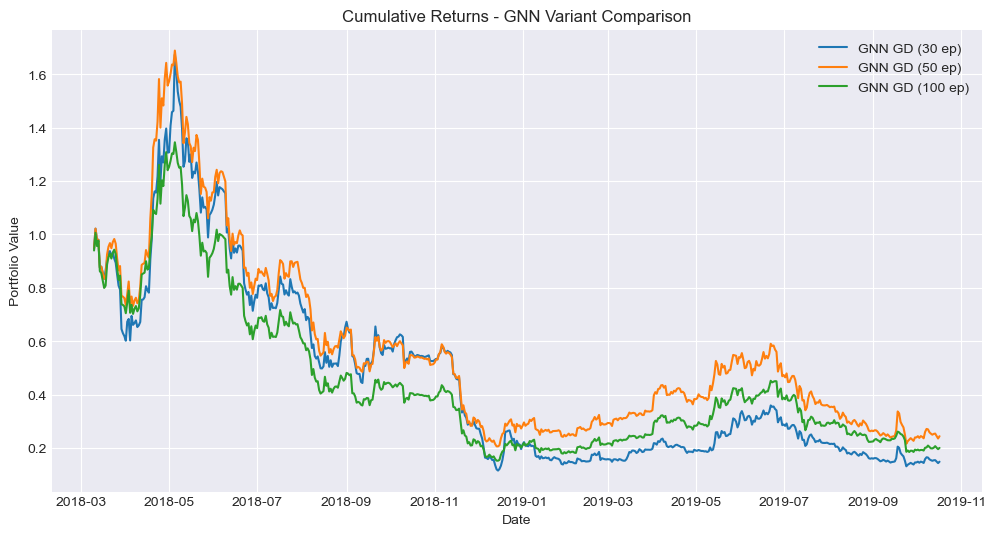

In [7]:
plt.figure(figsize=(12, 6))
for name, res in results.items():
    plt.plot(res['date'], res['cumulative_return'], label=name)

plt.title('Cumulative Returns - GNN Variant Comparison')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()